<a href="https://colab.research.google.com/github/Gafinhords/Restaurant-visitors-forecast/blob/main/01_eda1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
VISITS_PATH = "/content/air_visit_data.csv"
DATES_PATH = "/content/date_info.csv"

visits = pd.read_csv(VISITS_PATH, parse_dates=["visit_date"])
dates = pd.read_csv(DATES_PATH, parse_dates=["calendar_date"])

visits = visits.rename(columns={
    "air_store_id": "restaurant_id",
    "visit_date": "date",
    "visitors": "guests",
})
dates = dates.rename(columns={"calendar_date": "date"})[["date", "holiday_flg"]]
visits["restaurant_id"] = visits["restaurant_id"].astype("category").cat.codes.astype("int64")

df = visits.merge(dates, on="date", how="left")

print(f"Строк: {len(df):,}")
print(f"Ресторанов: {df['restaurant_id'].nunique()}")
print(f"Период: {df['date'].min().date()} … {df['date'].max().date()}")
df.head()

Строк: 252,108
Ресторанов: 829
Период: 2016-01-01 … 2017-04-22


,restaurant_id,date,guests,holiday_flg
0,603,2016-01-13,25,0
1,603,2016-01-14,32,0
2,603,2016-01-15,29,0
3,603,2016-01-16,22,0
4,603,2016-01-18,6,0


In [3]:
df["dow"] = df["date"].dt.dayofweek          # 0=Пн, 6=Вс
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["is_weekend"] = df["dow"].isin([4, 5, 6]).astype(int)   # пт, сб, вс

print(df[["date", "restaurant_id", "guests", "holiday_flg", "dow", "month", "year"]].head())

        date  restaurant_id  guests  holiday_flg  dow  month  year
0 2016-01-13            603      25            0    2      1  2016
1 2016-01-14            603      32            0    3      1  2016
2 2016-01-15            603      29            0    4      1  2016
3 2016-01-16            603      22            0    5      1  2016
4 2016-01-18            603       6            0    0      1  2016


## 1. Динамика по времени

Смотрим средний поток гостей по всем ресторанам. Сырой ряд шумный (недельные зубцы), поэтому накладываем скользящее среднее на 7 дней оно показывает тренд.

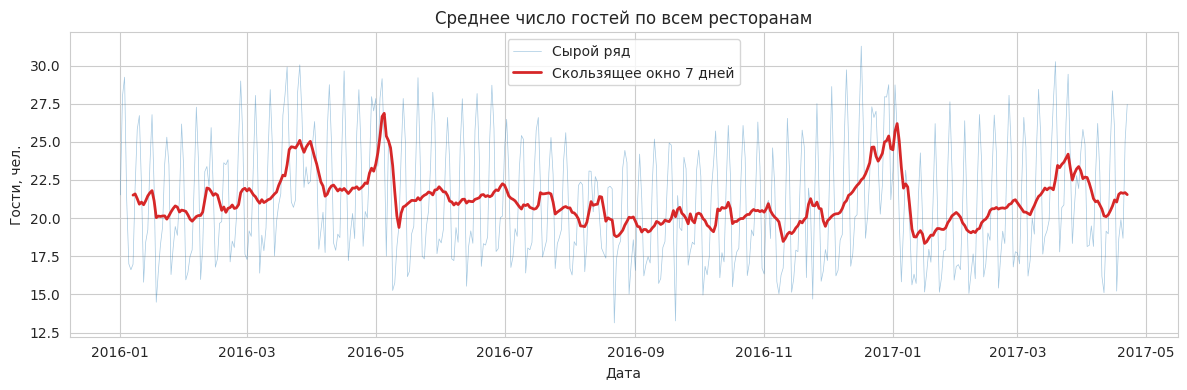

In [4]:
daily = df.groupby("date")["guests"].mean()

fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, lw=0.5, alpha=0.4, label="Сырой ряд")
ax.plot(daily.index, daily.rolling(7).mean(), lw=2, color="C3", label="Скользящее окно 7 дней")
ax.set_title("Среднее число гостей по всем ресторанам")
ax.set_xlabel("Дата")
ax.set_ylabel("Гости, чел.")
ax.legend()
plt.tight_layout()
plt.show()

**Вывод.** После сглаживания выраженного тренда нет  уровень держится 20–23 гостя. Видны два пика: **конец марта начало апреля** (цветение сакуры) и **конец декабря - начало января** (Новый год). Провал в январе 2017 это постпраздничный спад

**Для модели:** линейный тренд не нужен, но критичны календарные признаки (месяц, день года) и лаги, чтобы поймать повторяющиеся события

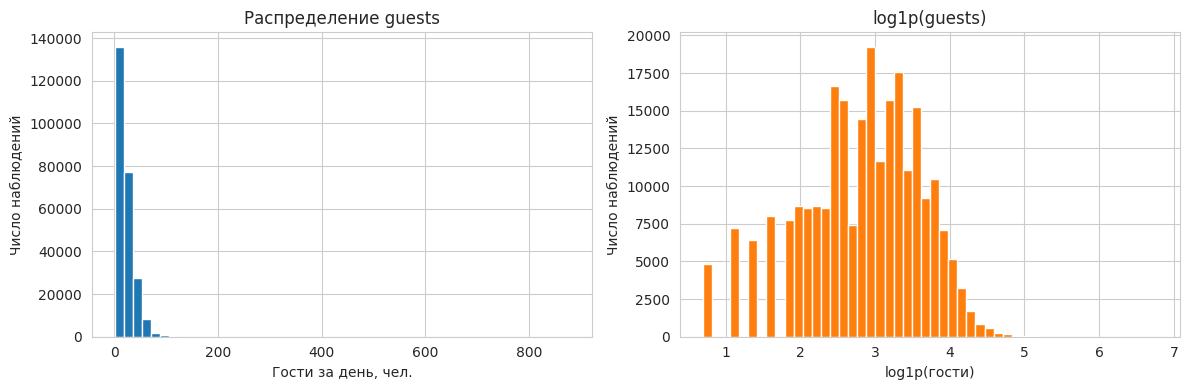

count    252108.000000
mean         20.973761
std          16.757007
min           1.000000
25%           9.000000
50%          17.000000
75%          29.000000
max         877.000000
Name: guests, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["guests"], bins=50, color="C0")
axes[0].set_title("Распределение guests")
axes[0].set_xlabel("Гости за день, чел.")
axes[0].set_ylabel("Число наблюдений")

axes[1].hist(np.log1p(df["guests"]), bins=50, color="C1")
axes[1].set_title("log1p(guests)")
axes[1].set_xlabel("log1p(гости)")
axes[1].set_ylabel("Число наблюдений")

plt.tight_layout()
plt.show()

print(df["guests"].describe())

**Вывод.** Распределение сильно скошено влево. Большинство наблюдений в диапазоне 5–40 гостей, но есть длинный хвост до нескольких сотен это крупные рестораны. После `log1p` форма ближе к нормальной

**Для модели:** это аргумент в пользу `log`трансформации таргета или использования LightGBM, который устойчив к скошенности. В финальном пайплайне выбран второй вариант

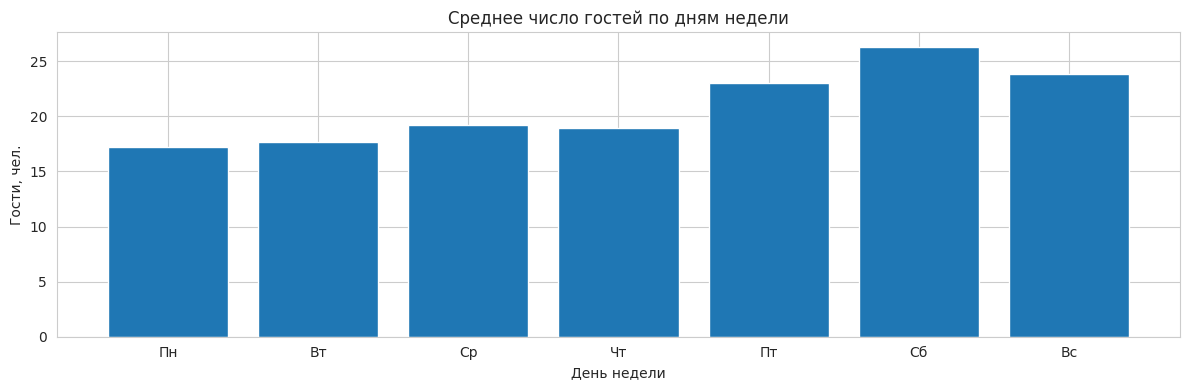

dow
0    17.18
1    17.67
2    19.23
3    18.92
4    23.07
5    26.31
6    23.87
Name: guests, dtype: float64


In [6]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
by_dow = df.groupby("dow")["guests"].mean()

fig, ax = plt.subplots()
ax.bar(dow_names, by_dow.values, color="C0")
ax.set_title("Среднее число гостей по дням недели")
ax.set_xlabel("День недели")
ax.set_ylabel("Гости, чел.")
plt.tight_layout()
plt.show()

print(by_dow.round(2))

**Вывод.** Четкий недельный паттерн. Пятница и суббота это пик (23–26 гостей), понедельник и вторник это минимум (17–18). Разница между пиком и провалом  **1.5 раза**.

**Для модели:** обязательны признаки `dow`, `is_weekend` и лаг 7, который переносит прошлую неделю на ту же позицию

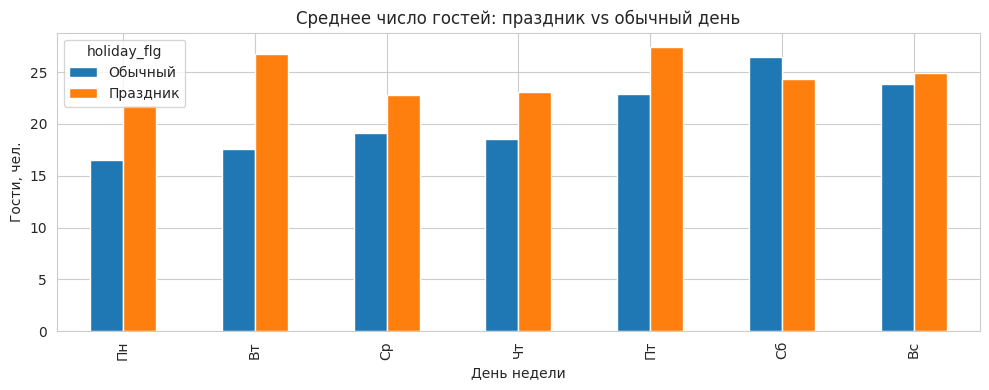

Разница (праздник − обычный):
Пн    5.33
Вт    9.22
Ср    3.60
Чт    4.51
Пт    4.55
Сб   -2.07
Вс    1.04
dtype: float64

Средняя разница: 3.74 гостя


In [7]:
pivot = df.pivot_table(
    index="dow", columns="holiday_flg", values="guests", aggfunc="mean"
)
pivot.index = dow_names

fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Среднее число гостей: праздник vs обычный день")
ax.set_xlabel("День недели")
ax.set_ylabel("Гости, чел.")
ax.legend(title="holiday_flg", labels=["Обычный", "Праздник"])
plt.tight_layout()
plt.show()

diff = (pivot[1] - pivot[0]).round(2)
print("Разница (праздник − обычный):")
print(diff)
print(f"\nСредняя разница: {diff.mean():.2f} гостя")

**Вывод.** Праздник даёт **+3.7 гостя в среднем** даже с учётом дня недели. Эффект максимален в будни (вт +9.2, пн +5.3, чт +4.5) праздник поднимает слабые дни почти до уровня выходного. В субботу эффект отрицательный (−2.1) вероятно, часть потока перераспределяется

**Для модели:** `holiday_flg` независимый признак, но одного его мало. Нужен ещё `day_after_holiday` для постпраздничного спада

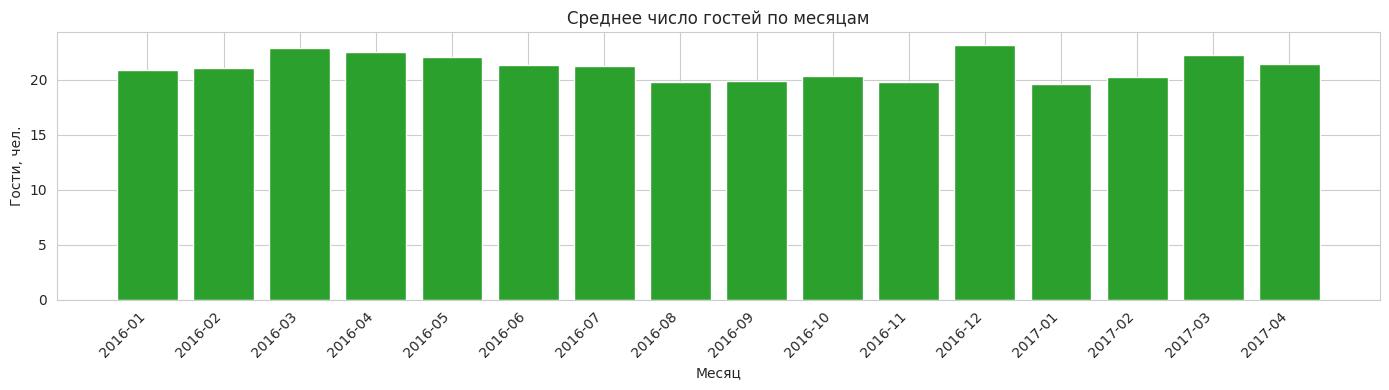

In [8]:
by_month = df.groupby("year_month")["guests"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(by_month.index, by_month.values, color="C2")
ax.set_title("Среднее число гостей по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Гости, чел.")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Вывод.** Март показывает повторяющийся пик в оба года (2016 и 2017) это воспроизводимый эффект цветения сакуры. Декабрь 2016 высокий, но с чем сравнить не можем данных за декабрь 2017 нет. Август и январь просадки

**Для модели:** называть это годовой сезонностью некорректно, правильнее помесячная динамика. Признак `month` можно добавить, но не ждать от него чудес. Основной сигнал о событиях пойдёт через `day` и `week_of_year

In [9]:
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
full_idx = pd.MultiIndex.from_product(
    [df["restaurant_id"].unique(), full_range],
    names=["restaurant_id", "date"],
)
full = pd.DataFrame(index=full_idx).reset_index()

merged = full.merge(
    df[["restaurant_id", "date", "guests"]],
    on=["restaurant_id", "date"], how="left",
)
merged["is_missing"] = merged["guests"].isna()

print(f"Доля пропусков: {merged['is_missing'].mean() * 100:.2f}%")
print(f"Пропусков всего: {merged['is_missing'].sum():,}")

Доля пропусков: 36.38%
Пропусков всего: 144,154


Ресторанов с 0% пропусков: 0
Ресторанов с <10% пропусков: 106
Ресторанов с 10–50% пропусков: 544
Ресторанов с >50% пропусков: 171


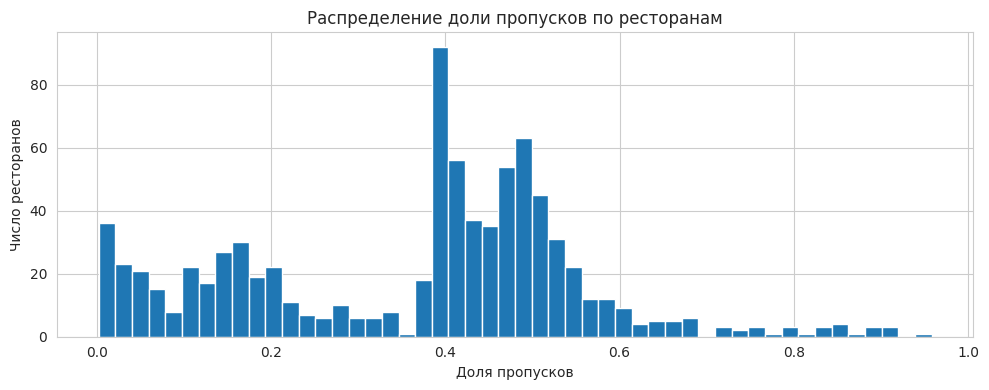

In [10]:
by_store = merged.groupby("restaurant_id")["is_missing"].agg(["mean", "sum"])

print(f"Ресторанов с 0% пропусков: {(by_store['mean'] == 0).sum()}")
print(f"Ресторанов с <10% пропусков: {(by_store['mean'] < 0.1).sum()}")
print(f"Ресторанов с 10–50% пропусков: {((by_store['mean'] >= 0.1) & (by_store['mean'] < 0.5)).sum()}")
print(f"Ресторанов с >50% пропусков: {(by_store['mean'] > 0.5).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
by_store["mean"].hist(bins=50, ax=ax, color="C0")
ax.set_title("Распределение доли пропусков по ресторанам")
ax.set_xlabel("Доля пропусков")
ax.set_ylabel("Число ресторанов")
plt.tight_layout()
plt.show()

**Вывод.** Распределение бимодальное — два горба около. Это значит, что часть ресторанов отчитывалась не каждый день либо работали, но не подавали данные, а часть открывалась или закрывалась в середине периода. Только 106 ресторанов имеют <10% пропусков

**Для модели:** фильтруем до ресторанов с долей пропусков <10%, так мы убираем неоднозначные случаи, где нельзя отличить закрытие от сбоя.

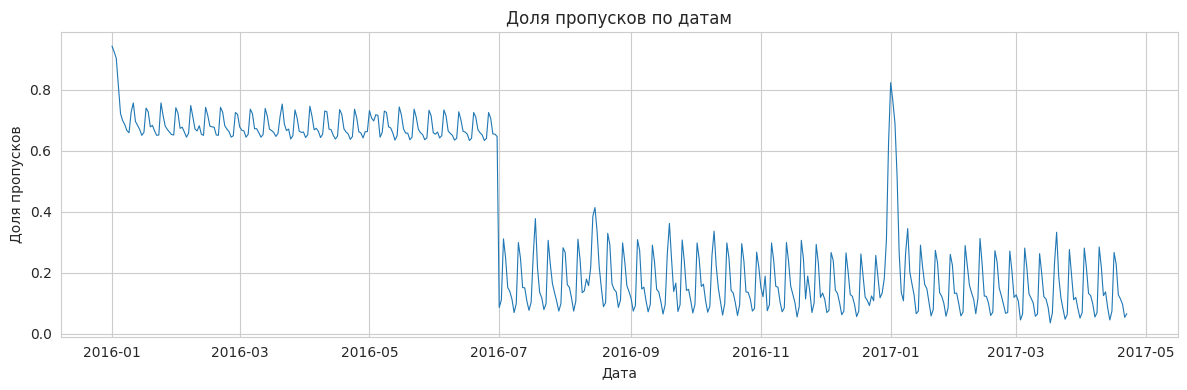

date
2016-01-01    0.942099
2016-01-02    0.924005
2016-01-03    0.902292
2017-01-01    0.822678
2016-01-04    0.810615
2017-01-02    0.763571
2016-01-24    0.756333
2016-01-11    0.756333
2016-03-21    0.752714
2016-02-07    0.747889
Name: is_missing, dtype: float64


In [11]:
by_date = merged.groupby("date")["is_missing"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(by_date.index, by_date.values, lw=0.8)
ax.set_title("Доля пропусков по датам")
ax.set_xlabel("Дата")
ax.set_ylabel("Доля пропусков")
plt.tight_layout()
plt.show()

print(by_date.sort_values(ascending=False).head(10))

**Вывод.** До июля 2016 доля пропусков 70%, после резко падает до 20–30%. Это значит, что в первой половине 2016 в системе было мало ресторанов, а с июля подключилась большая часть. Плюс пики 1 января это реальное закрытие на Новый год

**Для модели:** если обучаться на периоде, где половина ресторанов отсутствует, а валидироваться где они есть, метрики будут нечестными. Нужен фильтр по ресторанам с полной историей

In [12]:
dow_missing = merged.copy()
dow_missing["dow"] = dow_missing["date"].dt.dayofweek

by_dow_missing = dow_missing.groupby("dow")["is_missing"].mean().round(3)
by_dow_missing.index = dow_names
print(by_dow_missing)

Пн    0.438
Вт    0.361
Ср    0.347
Чт    0.326
Пт    0.295
Сб    0.314
Вс    0.468
Name: is_missing, dtype: float64


**Вывод.** Пик пропусков понедельник (0.438) и воскресенье (0.468). Минимум пятница (0.295). Это не случайность, многие заведения закрыты в понедельник и частично в воскресенье. Пропуски связаны с бизнесом

**Для модели:** заполнять пропуски нулями корректно (ресторан закрыт = 0 гостей), но только после фильтрации, иначе мы заполним нулями и рестораны, которых вообще не было в системе

In [13]:
by_store = merged.groupby("restaurant_id")["is_missing"].mean()
good_stores = by_store[by_store < 0.1].index

real = merged[~merged["is_missing"] & merged["restaurant_id"].isin(good_stores)]
span = real.groupby("restaurant_id")["date"].agg(["min", "max"])
span["days"] = (span["max"] - span["min"]).dt.days
full_stores = span[span["days"] > 400].index

df_clean = df[df["restaurant_id"].isin(full_stores)].copy().reset_index(drop=True)

print(f"Ресторанов осталось: {df_clean['restaurant_id'].nunique()}")
print(f"Строк: {len(df_clean):,}")

Ресторанов осталось: 106
Строк: 48,591


Доля пропусков: 4.10%


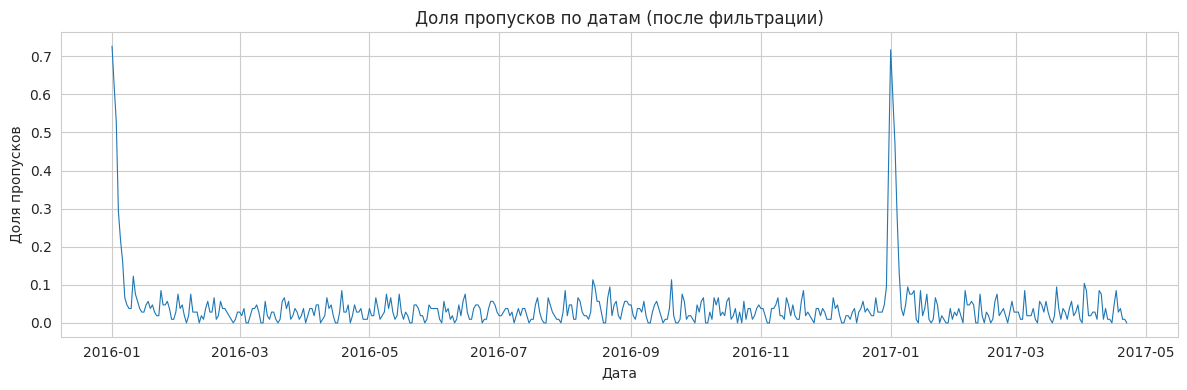

In [14]:
full_range = pd.date_range(df_clean["date"].min(), df_clean["date"].max(), freq="D")
full_idx = pd.MultiIndex.from_product(
    [df_clean["restaurant_id"].unique(), full_range],
    names=["restaurant_id", "date"],
)
full2 = pd.DataFrame(index=full_idx).reset_index()

merged2 = full2.merge(
    df_clean[["restaurant_id", "date", "guests"]],
    on=["restaurant_id", "date"], how="left",
)
merged2["is_missing"] = merged2["guests"].isna()

print(f"Доля пропусков: {merged2['is_missing'].mean() * 100:.2f}%")

by_date2 = merged2.groupby("date")["is_missing"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(by_date2.index, by_date2.values, lw=0.8)
ax.set_title("Доля пропусков по датам (после фильтрации)")
ax.set_xlabel("Дата")
ax.set_ylabel("Доля пропусков")
plt.tight_layout()
plt.show()

**Вывод.** После фильтрации доля пропусков упала с 36% до 4.1%. Остались два кластера край истории (январь 2016) и 1 января 2017, реальное закрытие ресторанов. Остальные пропуски совпадают с выходными

**Для модели:** 4.1% приемлемый уровень. Стратегия заполнить нулями при восстановлении календаря (закрытые дни = 0 гостей) это уже реализовано в `src/data.py::restore_calendar`.

In [15]:
stats = df_clean.groupby("restaurant_id")["guests"].agg(
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
)
stats["iqr"] = stats["q3"] - stats["q1"]
stats["upper"] = stats["q3"] + 3 * stats["iqr"]

df_clean = df_clean.merge(stats[["upper"]], left_on="restaurant_id", right_index=True)
df_clean["is_outlier"] = df_clean["guests"] > df_clean["upper"]

n_out = df_clean["is_outlier"].sum()
print(f"Выбросов: {n_out} ({df_clean['is_outlier'].mean() * 100:.2f}%)")

Выбросов: 102 (0.21%)


In [16]:
out_hol = df_clean[df_clean["is_outlier"]]

print(f"Из {len(out_hol)} выбросов в праздники: {out_hol['holiday_flg'].sum()}")
print(f"Доля праздничных среди выбросов: {out_hol['holiday_flg'].mean():.3f}")
print(f"Доля праздничных во всём датасете: {df_clean['holiday_flg'].mean():.3f}")

Из 102 выбросов в праздники: 11
Доля праздничных среди выбросов: 0.108
Доля праздничных во всём датасете: 0.056


**Вывод.** Обнаружено 102 выброса (0.21%). Проверка показала: 10.8% из них приходятся на праздники, что вдвое выше базовой доли праздников в данных (5.6%). Это подтверждает часть выбросов это реальные праздничные пики, а не ошибки. Оставшиеся 89% вероятно, локальные события (корпоративы, банкеты) или крупные рестораны с низким порогом IQR

**Решение: выбросы не удалять.** LightGBM устойчив к редким пикам, а сами пики  часть бизнеса, которую модель должна знать

In [17]:
import os
os.makedirs("data/processed", exist_ok=True)

full_range = pd.date_range(df_clean["date"].min(), df_clean["date"].max(), freq="D")
full_idx = pd.MultiIndex.from_product(
    [df_clean["restaurant_id"].unique(), full_range],
    names=["restaurant_id", "date"],
)
full = pd.DataFrame(index=full_idx).reset_index()

df_final = full.merge(
    df_clean[["restaurant_id", "date", "guests", "holiday_flg"]],
    on=["restaurant_id", "date"], how="left",
)
df_final["guests"] = df_final["guests"].fillna(0).astype("int64")
df_final["holiday_flg"] = df_final["holiday_flg"].fillna(0).astype("int64")

# revenue: моделируем как guests × 2500 ₽ × шум(5%) — как в src/data.py
rng = np.random.default_rng(42)
df_final["revenue"] = (
    df_final["guests"].astype(float) * 2500.0 * rng.normal(1.0, 0.05, len(df_final))
).astype("float64")

df_final = df_final[["date", "restaurant_id", "guests", "revenue", "holiday_flg"]]
df_final = df_final.sort_values(["restaurant_id", "date"]).reset_index(drop=True)

df_final.to_csv("data/processed/df_clean.csv", index=False)

print(f"Сохранено: {len(df_final):,} строк")
print(f"Ресторанов: {df_final['restaurant_id'].nunique()}")
print(f"Доля нулевых дней (закрыто): {(df_final['guests'] == 0).mean() * 100:.2f}%")

Сохранено: 50,668 строк
Ресторанов: 106
Доля нулевых дней (закрыто): 4.10%


## Итоговые выводы EDA

1. **Тренда нет** — уровень потока держится на 20–23 гостя. Для модели это значит, что линейный тренд не нужен, но календарные признаки и лаги критичны

2. **Недельная сезонность сильная** пик в пятницу-субботу, провал в понедельник-вторник, разница 1.5 раза. Обосновывает признаки `dow`, `is_weekend` и лаг 7

3. **Праздники дают +3.7 гостя** сверх дня недели. Эффект сильнее в будни. Обосновывает `is_holiday` и `day_after_holiday`

4. **Годовая сезонность не выделяется** - 16 месяцев недостаточно. Март даёт повторяющийся пик в оба года (цветение сакуры). Признак `month` добавляем, но без больших ожиданий

5. **Распределение `guests` скошено вправо** — аргумент за `log1p` или использование LightGBM без трансформации

6. **36% пропусков в 4.1%** после фильтрации до 106 ресторанов с полной историей. Пропуски связаны с выходными (пн, вс), то есть с бизнес логикой

7. **Выбросов 0.21%** — не удаляем, они часть бизнеса. 10.8% из них приходятся на праздники (вдвое выше базовой ставки)

Финальный датасет сохранён в `data/processed/df_clean.csv` — 106 ресторанов, восстановленный календарь с закрытыми днями (guests = 0)